In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

        date  gold_last  gold_open  gold_high  gold_low  gold_volume  \
0 1993-01-01      333.1      333.3      333.5     333.0      20180.0   
1 1993-01-02      333.1      333.3      333.5     333.0      20180.0   
2 1993-01-03      333.1      333.3      333.5     333.0      20180.0   
3 1993-01-04      328.4      329.1      329.4     326.5      14850.0   
4 1993-01-05      329.0      329.0      329.5     328.5      20380.0   

   gold_change_percent  
0                -0.06  
1                -0.06  
2                -0.06  
3                -1.41  
4                 0.18  


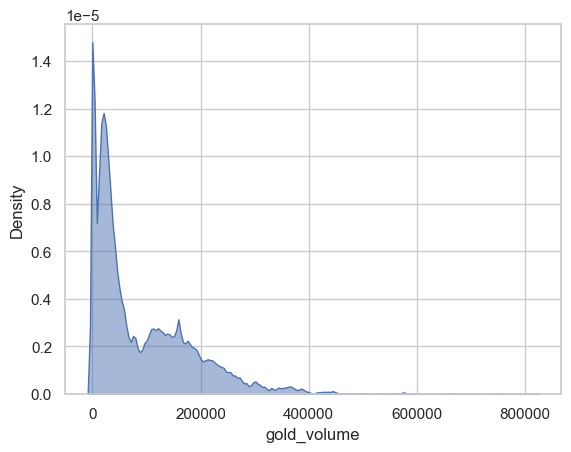

In [4]:
sns.set_theme(style="whitegrid")

file_path = "../data/gold_cleaned.csv"
df = pd.read_csv(file_path, parse_dates=["date"])

print(df.head())

sns.kdeplot(df, x="gold_volume", fill=True, common_norm=False, alpha=0.5, bw_adjust=0.2)
plt.show()

In [5]:
Q1 = df["gold_volume"].quantile(0.25)
Q3 = df["gold_volume"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")


Q1: 19052.5
Q3: 145350.0
IQR: 126297.5
Lower Bound: -170393.75
Upper Bound: 334796.25


In [ ]:
outliers = df[(df["gold_volume"] < lower_bound) | (df["gold_volume"] > upper_bound)]
print(f"Số lượng outliers: {len(outliers)}")
df_no_outliers = df[(df["gold_volume"] >= lower_bound) & (df["gold_volume"] <= upper_bound)]

Số lượng outliers: 265


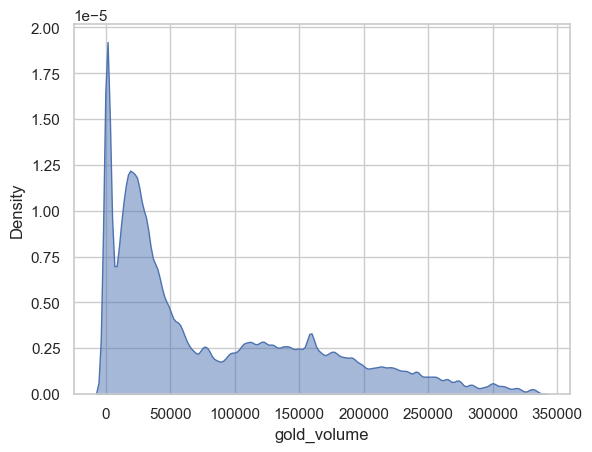

In [7]:
sns.kdeplot(df_no_outliers, x="gold_volume", fill=True, common_norm=False, alpha=0.5, bw_adjust=0.2)
plt.show()

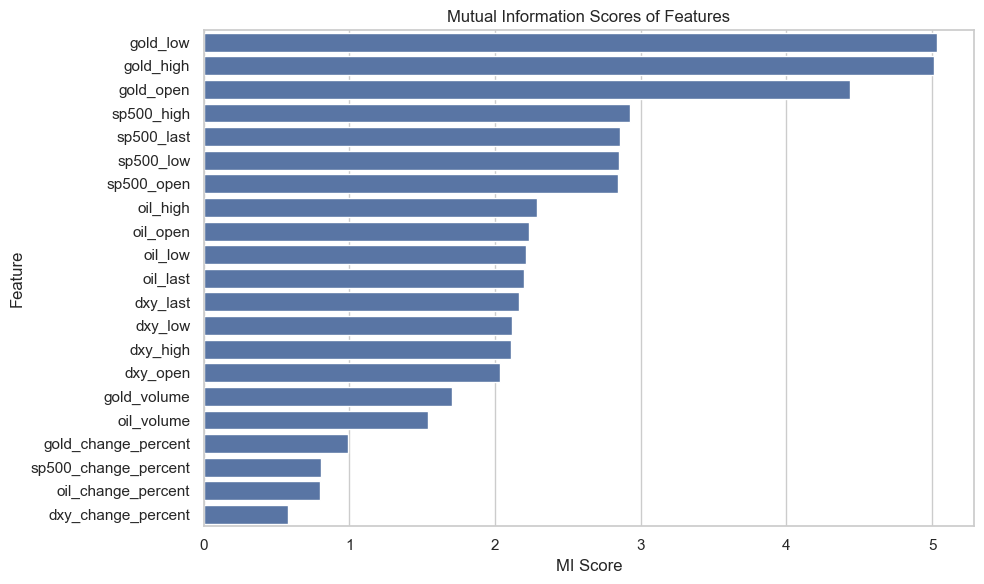

In [16]:
from sklearn.feature_selection import mutual_info_regression

def evaluate_feature_correlation(df):
    features = df.select_dtypes(include=["number"]).drop(columns=["gold_last"]).copy()
    target = df["gold_last"]

    mi_score = mutual_info_regression(features, target, random_state=42)
    mi_df = pd.DataFrame({"Feature": features.columns, "MI Score": mi_score})
    mi_df = mi_df.sort_values(by="MI Score", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=mi_df, x="MI Score", y="Feature")
    plt.title("Mutual Information Scores of Features")
    plt.tight_layout()
    plt.show()

df = pd.read_csv("../data/merged_gold_data.csv", parse_dates=["date"])
evaluate_feature_correlation(df)

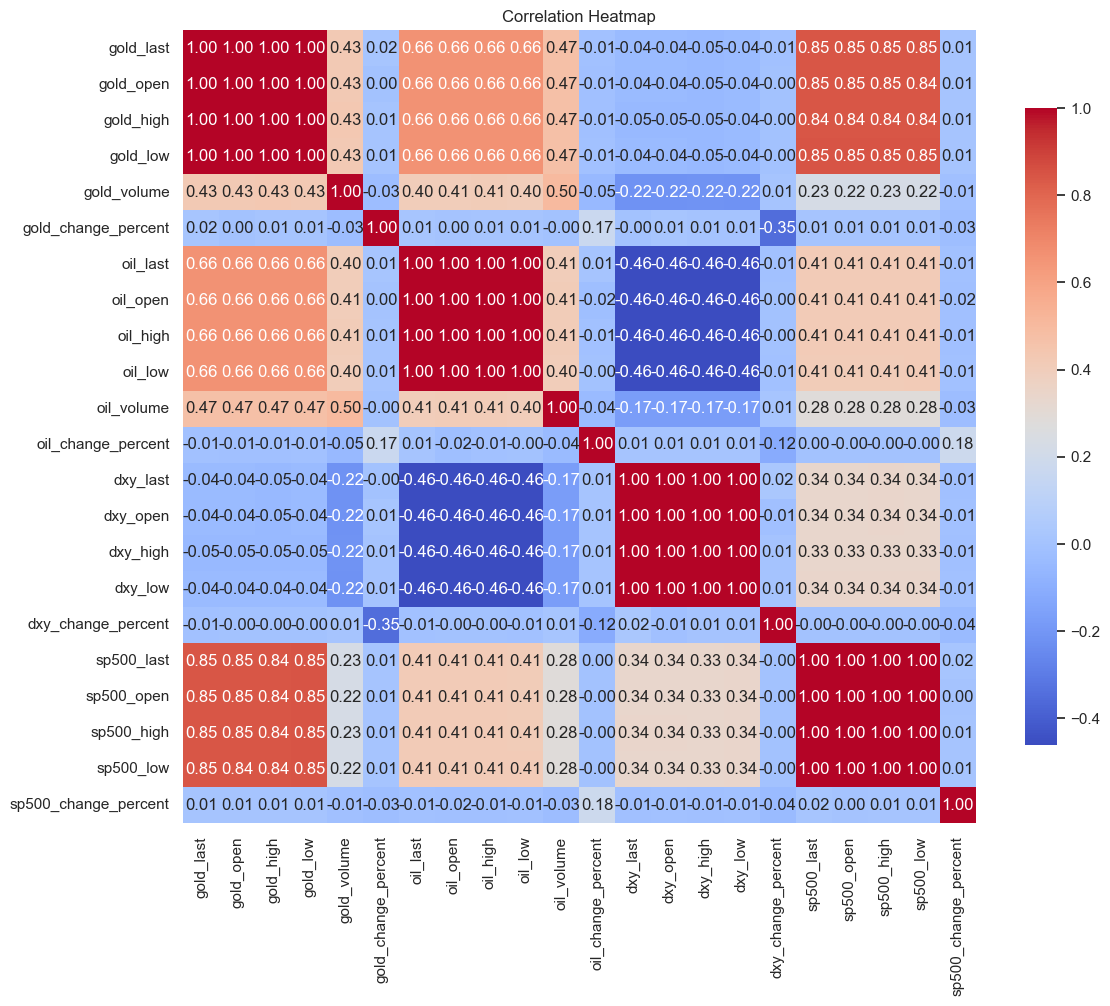

In [21]:
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=["number"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
n_lags = 5

for feat in df.columns:
    for i in range(1, n_lags + 1):
        df[f"{feat}_lag_{i}"] = df[feat].shift(i)

In [24]:
df = df.dropna().reset_index(drop=True)

In [25]:
df['target'] = df['gold_last'].shift(-1)

In [26]:
drop_cols = ['date', 'gold_last', 'gold_change_percent', 'target']
feature_cols = [col for col in df.columns if col not in drop_cols]

In [30]:
df[feature_cols].dtypes

gold_open                     float64
gold_high                     float64
gold_low                      float64
gold_volume                   float64
oil_last                      float64
                               ...   
sp500_change_percent_lag_1    float64
sp500_change_percent_lag_2    float64
sp500_change_percent_lag_3    float64
sp500_change_percent_lag_4    float64
sp500_change_percent_lag_5    float64
Length: 135, dtype: object

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_feature_cols = df[feature_cols].select_dtypes(include=["number"]).columns
df[numeric_feature_cols] = scaler.fit_transform(df[numeric_feature_cols])
